In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df= pd.read_csv("data/credit_risk_dataset.csv")

In [6]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.columns.tolist() 

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [8]:
df.shape

(32581, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [10]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [11]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [12]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32576    False
32577    False
32578    False
32579    False
32580    False
Length: 32581, dtype: bool

In [13]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [14]:
df_clean = df.copy()

In [15]:
df_clean = df_clean.rename(columns={
    "cb_person_default_on_file": "prior_default",
    "cb_person_cred_hist_length": "cred_hist_length",
    "loan_percent_income": "loan_to_income"
})

In [16]:
emp_median= df_clean["person_emp_length"].median()
df_clean["person_emp_legth"] = df_clean['person_emp_length'].fillna(emp_median)

In [17]:
# loan_int_rate: fill with median by loan_grade (more accurate)
df_clean["loan_int_rate"] = df_clean.groupby("loan_grade")["loan_int_rate"].transform(
    lambda x: x.fillna(x.median())
)

In [18]:
df_clean.isnull().sum()

person_age                 0
person_income              0
person_home_ownership      0
person_emp_length        895
loan_intent                0
loan_grade                 0
loan_amnt                  0
loan_int_rate              0
loan_status                0
loan_to_income             0
prior_default              0
cred_hist_length           0
person_emp_legth           0
dtype: int64

# Key KPIs

In [19]:
total_loans = len(df_clean)
defaults = df_clean["loan_status"].sum()
default_rate = defaults / total_loans *100

In [20]:
print(f"Total loans : {total_loans:,}")
print(f"Ddefualts : {defaults:,}")
print(f"Overall Default Rate : {default_rate:.2f}%")
print(f"Avg Loan Amount : ${df_clean['loan_amnt'].mean():,.0f}")
print(f"Avg Interest Rate : {df_clean['loan_int_rate'].mean():.2f}%")
print(f"Avg Loan-to-Income : {df_clean['loan_to_income'].mean()*100:.1f}%")
print(f"Avg Credit History : {df_clean['cred_hist_length'].mean():.1f} years")

Total loans : 32,581
Ddefualts : 7,108
Overall Default Rate : 21.82%
Avg Loan Amount : $9,589
Avg Interest Rate : 11.01%
Avg Loan-to-Income : 17.0%
Avg Credit History : 5.8 years


# Default Rate by Important Segments

In [21]:
def default_by(col):
    result = (
        df_clean.groupby(col)
        .agg(
            loans=("loan_status", "count"),
            defaults=("loan_status", "sum"),
            default_rate=("loan_status", "mean")
        )
        .assign(default_rate=lambda x: (x["default_rate"]*100).round(2))
        .sort_values("default_rate", ascending=False)
    )
    return result

In [22]:
print("\n--- Default Rate by Loan Grade ---")
display(default_by("loan_grade"))

print("\n--- Default Rate by Loan Intent ---")
display(default_by("loan_intent"))

print("\n--- Default Rate by Home Ownership ---")
display(default_by("person_home_ownership"))

print("\n--- Default Rate by Prior Default Flag ---")
display(default_by("prior_default"))


--- Default Rate by Loan Grade ---


,loans,defaults,default_rate
loan_grade,,,
G,64,63,98.44
F,241,170,70.54
E,964,621,64.42
D,3626,2141,59.05
C,6458,1339,20.73
B,10451,1701,16.28
A,10777,1073,9.96



--- Default Rate by Loan Intent ---


,loans,defaults,default_rate
loan_intent,,,
DEBTCONSOLIDATION,5212,1490,28.59
MEDICAL,6071,1621,26.70
HOMEIMPROVEMENT,3605,941,26.10
PERSONAL,5521,1098,19.89
EDUCATION,6453,1111,17.22
VENTURE,5719,847,14.81



--- Default Rate by Home Ownership ---


,loans,defaults,default_rate
person_home_ownership,,,
RENT,16446,5192,31.57
OTHER,107,33,30.84
MORTGAGE,13444,1690,12.57
OWN,2584,193,7.47



--- Default Rate by Prior Default Flag ---


,loans,defaults,default_rate
prior_default,,,
Y,5745,2172,37.81
N,26836,4936,18.39


# Simple Risk Flags (same spirit as original project)

In [23]:
df_clean["flag_high_lti"] = (df_clean["loan_to_income"] >= 0.40).astype(int)
df_clean["flag_bad_grade"] = df_clean["loan_grade"].isin(["D", "E", "F", "G"]).astype(int)
df_clean["flag_prior_default"] = (df_clean["prior_default"] == "Y").astype(int)

df_clean["risk_score"] = (
    df_clean["flag_high_lti"] +
    df_clean["flag_bad_grade"] +
    df_clean["flag_prior_default"]
)

print("\n--- Risk Score Performance ---")
display(default_by("risk_score"))


--- Risk Score Performance ---


,loans,defaults,default_rate
risk_score,,,
3,130,117,90.00
2,2621,1629,62.15
1,6343,2541,40.06
0,23487,2821,12.01


# Charts

C:\Users\Aditya Gupta\AppData\Local\Temp\ipykernel_33680\2713791990.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_default.index, y=grade_default["default_rate"], palette="Reds_r")


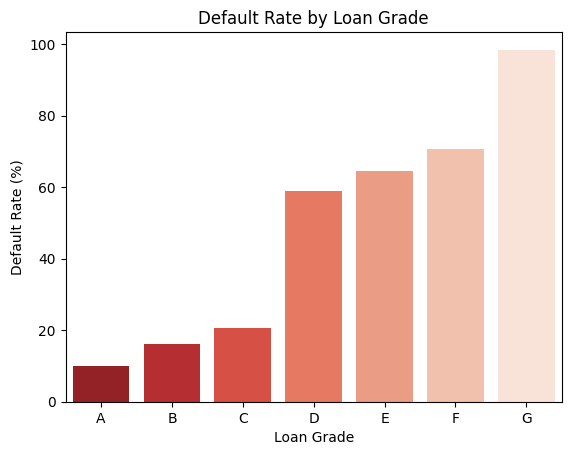

In [27]:
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
grade_default = default_by("loan_grade").reindex(grade_order)

plt.figure()
sns.barplot(x=grade_default.index, y=grade_default["default_rate"], palette="Reds_r")
plt.title("Default Rate by Loan Grade")
plt.ylabel("Default Rate (%)")
plt.xlabel("Loan Grade")
plt.show()

C:\Users\Aditya Gupta\AppData\Local\Temp\ipykernel_33680\1281621316.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=intent_default.index, x=intent_default["default_rate"], palette="Blues_r")


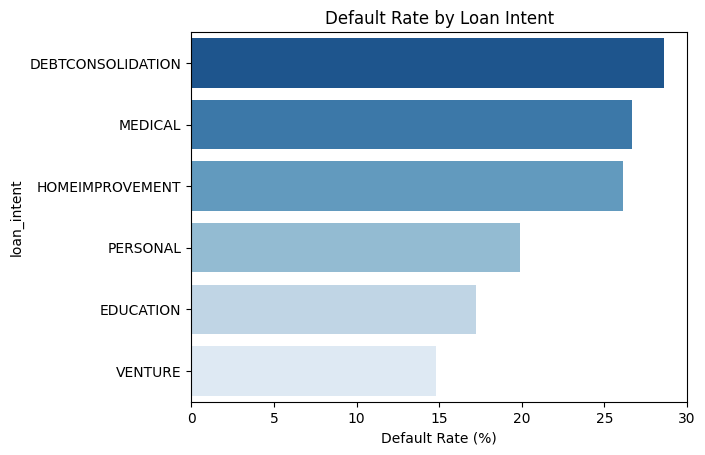

In [25]:
intent_default = default_by("loan_intent")
plt.figure()
sns.barplot(y=intent_default.index, x=intent_default["default_rate"], palette="Blues_r")
plt.title("Default Rate by Loan Intent")
plt.xlabel("Default Rate (%)")
plt.show()

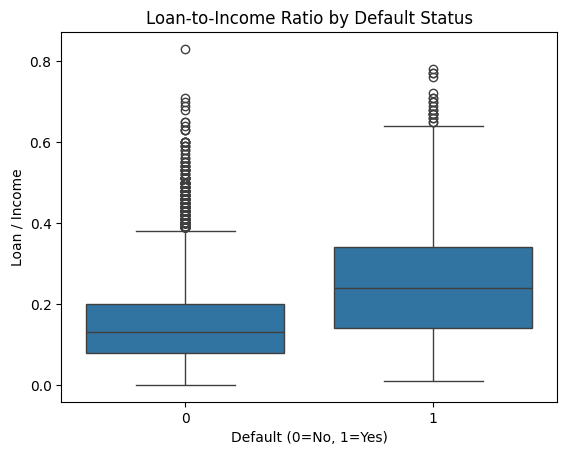

In [28]:
plt.figure()
sns.boxplot(x="loan_status", y="loan_to_income", data=df_clean)
plt.title("Loan-to-Income Ratio by Default Status")
plt.xlabel("Default (0=No, 1=Yes)")
plt.ylabel("Loan / Income")
plt.show()

C:\Users\Aditya Gupta\AppData\Local\Temp\ipykernel_33680\2000285564.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="risk_score", data=df_clean, palette="viridis")


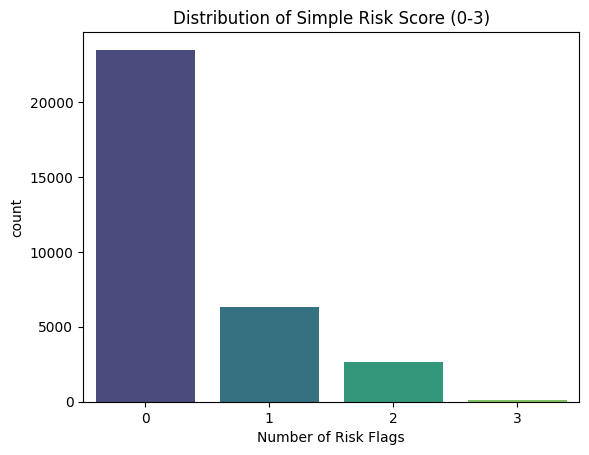

In [29]:
plt.figure()
sns.countplot(x="risk_score", data=df_clean, palette="viridis")
plt.title("Distribution of Simple Risk Score (0-3)")
plt.xlabel("Number of Risk Flags")
plt.show()

In [30]:
df_clean.to_csv("credit_risk_cleaned.csv", index=False)
print("\nCleaned file saved as → credit_risk_cleaned.csv")


Cleaned file saved as → credit_risk_cleaned.csv
